In [49]:
import asyncio, json, os
import websockets
from dotenv import load_dotenv
load_dotenv()
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
import geodatasets
import tqdm as notebook_tqdm
import contextily as cx
import requests
import sys

In [4]:
# load the ports from ports.csv
ports_df = pd.read_csv('data/Ports.csv')
choke_points_df = pd.read_csv('data/PortWatch_Chokepoints_database.csv')
combined_df = pd.concat([ports_df, choke_points_df], ignore_index=True)

In [19]:
combined_df.head(5)

,X,Y,portid,portname,country,ISO3,fullname,lat,lon,pageid,ObjectId,bounding_box
0,1.514731e+07,4.254924e+06,port1325,Tsuruga,Japan,JPN,"Tsuruga, Japan",35.667194,136.070611,3b1f40eb8acd452ab6229331302891fe,1,"(35.53219379, 135.9356107, 35.80219379, 136.20..."
1,1.099633e+07,1.931654e+05,port1198,Sibolga,Indonesia,IDN,"Sibolga, Indonesia",1.734969,98.781715,4d00b008b4be4068bf8a19d7da6e8cf6,2,"(1.599969159, 98.64671534, 1.869969159, 98.916..."
2,1.206306e+07,2.465269e+06,port339,Fangcheng,China,CHN,"Fangcheng, China",21.614205,108.364339,266042b244cf452a89f4a2de14f3da2f,3,"(21.47920534, 108.22933929999999, 21.749205340..."
3,1.460658e+07,4.021402e+06,port1335,Ube,Japan,JPN,"Ube, Japan",33.944875,131.213184,f3f6725ef00e4d3f8f9c93c45258667e,4,"(33.80987467, 131.0781838, 34.079874669999995,..."
4,1.874177e+07,-5.875428e+06,port153,Bluff Harbor,New Zealand,NZL,"Bluff Harbor, New Zealand",-46.590130,168.360216,894ab5e5a18e48b6922c023196f74c8f,5,"(-46.725129949999996, 168.22521600000002, -46...."


In [5]:
# for each port in the combined_df, add a new column called bounding box that contains the bounding box of the port in the format (min_lat, min_lon, max_lat, max_lon) within 15km
combined_df['bounding_box'] = None  
for index, row in combined_df.iterrows():
    lat = row['lat']
    lon = row['lon']
    min_lat = lat - 0.135
    max_lat = lat + 0.135
    min_lon = lon - 0.135
    max_lon = lon + 0.135
    combined_df.at[index, 'bounding_box'] = (min_lat, min_lon, max_lat, max_lon)

In [29]:
#drop some columns from the combined_df that are not needed
combined_df = combined_df.drop(columns=['X', 'Y', 'ISO3', 'fullname'])

In [31]:
combined_df.head(5)

,portid,portname,country,lat,lon,pageid,ObjectId,bounding_box
0,port1325,Tsuruga,Japan,35.667194,136.070611,3b1f40eb8acd452ab6229331302891fe,1,"(35.53219379, 135.9356107, 35.80219379, 136.20..."
1,port1198,Sibolga,Indonesia,1.734969,98.781715,4d00b008b4be4068bf8a19d7da6e8cf6,2,"(1.599969159, 98.64671534, 1.869969159, 98.916..."
2,port339,Fangcheng,China,21.614205,108.364339,266042b244cf452a89f4a2de14f3da2f,3,"(21.47920534, 108.22933929999999, 21.749205340..."
3,port1335,Ube,Japan,33.944875,131.213184,f3f6725ef00e4d3f8f9c93c45258667e,4,"(33.80987467, 131.0781838, 34.079874669999995,..."
4,port153,Bluff Harbor,New Zealand,-46.590130,168.360216,894ab5e5a18e48b6922c023196f74c8f,5,"(-46.725129949999996, 168.22521600000002, -46...."


In [35]:
# 1. Setup port and extract metadata fields from combined_df
target_port_name = "Hong Kong"  # Change to your port
port_row = combined_df[combined_df["portname"] == target_port_name].iloc[0]

min_lat, min_lon, max_lat, max_lon = port_row["bounding_box"]

# Extract the requested port identifiers and details
p_id = port_row.get("portid", port_row.get("id", None))
p_name = port_row.get("portname", target_port_name)
p_country = port_row.get("country", None)
p_pageid = port_row.get("pageid", None)

API_KEY = os.getenv("AISSTREAM_API_KEY")
STREAM_DURATION_SECONDS = 60 

async def stream_static_data(duration):
    data_list = []
    
    try:
        async with websockets.connect(
            "wss://stream.aisstream.io/v0/stream",
            compression="deflate",
        ) as ws:
            
            # Send subscription request for ShipStaticData ONLY
            await ws.send(json.dumps({
                "APIKey": API_KEY,
                "BoundingBoxes": [[[min_lat, min_lon], [max_lat, max_lon]]],
                "FilterMessageTypes": ["ShipStaticData"]
            }))
            
            print(f"Stream opened for {p_name} ({p_country}). Waiting {duration} seconds for static data...")

            async def receive_messages():
                async for payload in ws:
                    msg = json.loads(payload)
                    
                    if msg.get("MessageType") == "ShipStaticData":
                        meta = msg.get("MetaData", {})
                        report = msg.get("Message", {}).get("ShipStaticData", {})
                        
                        # Flatten dictionaries and attach port metadata fields directly to each row
                        row_data = {
                            **meta, 
                            **report,
                            "portid": p_id,
                            "portname": p_name,
                            "country": p_country,
                            "pageid": p_pageid
                        }
                        data_list.append(row_data)
                        
                        ship_name = meta.get("ShipName", "Unknown").strip()
                        print(f"Caught static data for: {ship_name}")

            # Enforce the time limit
            await asyncio.wait_for(receive_messages(), timeout=duration)
            
    except asyncio.TimeoutError:
        print("\nTime limit reached. Closing stream.")
    except Exception as e:
        print(f"An error occurred: {e}")

    # Convert to DataFrame
    df = pd.DataFrame(data_list)
    return df

# Await the function and store the result
static_df = await stream_static_data(STREAM_DURATION_SECONDS)
display(static_df.head())

Stream opened for Hong Kong (Hong Kong SAR). Waiting 60 seconds for static data...
Caught static data for: TONG WEI
Caught static data for: NEW HOPE
Caught static data for: MSC TRADER II
Caught static data for: XIN MING ZHU XXXIX
Caught static data for: WING YIP 3
Caught static data for: YUE HANG 337
Caught static data for: ZHONG RAN 23
Caught static data for: HU SHAN
Caught static data for: SHUN KING
Caught static data for: MAN FOO

Time limit reached. Closing stream.


,MMSI,MMSI_String,ShipName,latitude,longitude,time_utc,AisVersion,CallSign,Destination,Dimension,...,Name,RepeatIndicator,Spare,Type,UserID,Valid,portid,portname,country,pageid
0,477996977,477996977,TONG WEI,22.30852,114.15568,2026-09-11 02:07:02.668653436 +0000 UTC,2,VRS6261,XHQ,"{'A': 12, 'B': 13, 'C': 3, 'D': 4}",...,TONG WEI,0,False,31,477996977,True,port474,Hong Kong,Hong Kong SAR,b08dc280fe0f4667aec5343c54bff807
1,477997094,477997094,NEW HOPE,22.36770,114.10326,2026-09-11 02:07:14.028961136 +0000 UTC,1,VRS6378,HONG KONG,"{'A': 29, 'B': 12, 'C': 8, 'D': 8}",...,NEW HOPE,0,False,80,477997094,True,port474,Hong Kong,Hong Kong SAR,b08dc280fe0f4667aec5343c54bff807
2,636020978,636020978,MSC TRADER II,22.32965,114.11666,2026-09-11 02:07:19.028564869 +0000 UTC,2,5LBQ9,SHEKOU,"{'A': 164, 'B': 20, 'C': 14, 'D': 11}",...,MSC TRADER II,0,False,70,636020978,True,port474,Hong Kong,Hong Kong SAR,b08dc280fe0f4667aec5343c54bff807
3,477997175,477997175,XIN MING ZHU XXXIX,22.29415,114.19999,2026-09-11 02:07:19.068745817 +0000 UTC,2,VRS6423,HONG KONG,"{'A': 16, 'B': 19, 'C': 5, 'D': 6}",...,XIN MING ZHU XXXIX,0,False,60,477997175,True,port474,Hong Kong,Hong Kong SAR,b08dc280fe0f4667aec5343c54bff807
4,477995530,477995530,WING YIP 3,22.28750,114.18763,2026-09-11 02:07:25.245232244 +0000 UTC,2,VRS4866,U,"{'A': 2, 'B': 15, 'C': 1, 'D': 4}",...,WING YIP 3,0,False,60,477995530,True,port474,Hong Kong,Hong Kong SAR,b08dc280fe0f4667aec5343c54bff807


In [36]:
static_df.head(5)

,MMSI,MMSI_String,ShipName,latitude,longitude,time_utc,AisVersion,CallSign,Destination,Dimension,...,Name,RepeatIndicator,Spare,Type,UserID,Valid,portid,portname,country,pageid
0,477996977,477996977,TONG WEI,22.30852,114.15568,2026-09-11 02:07:02.668653436 +0000 UTC,2,VRS6261,XHQ,"{'A': 12, 'B': 13, 'C': 3, 'D': 4}",...,TONG WEI,0,False,31,477996977,True,port474,Hong Kong,Hong Kong SAR,b08dc280fe0f4667aec5343c54bff807
1,477997094,477997094,NEW HOPE,22.36770,114.10326,2026-09-11 02:07:14.028961136 +0000 UTC,1,VRS6378,HONG KONG,"{'A': 29, 'B': 12, 'C': 8, 'D': 8}",...,NEW HOPE,0,False,80,477997094,True,port474,Hong Kong,Hong Kong SAR,b08dc280fe0f4667aec5343c54bff807
2,636020978,636020978,MSC TRADER II,22.32965,114.11666,2026-09-11 02:07:19.028564869 +0000 UTC,2,5LBQ9,SHEKOU,"{'A': 164, 'B': 20, 'C': 14, 'D': 11}",...,MSC TRADER II,0,False,70,636020978,True,port474,Hong Kong,Hong Kong SAR,b08dc280fe0f4667aec5343c54bff807
3,477997175,477997175,XIN MING ZHU XXXIX,22.29415,114.19999,2026-09-11 02:07:19.068745817 +0000 UTC,2,VRS6423,HONG KONG,"{'A': 16, 'B': 19, 'C': 5, 'D': 6}",...,XIN MING ZHU XXXIX,0,False,60,477997175,True,port474,Hong Kong,Hong Kong SAR,b08dc280fe0f4667aec5343c54bff807
4,477995530,477995530,WING YIP 3,22.28750,114.18763,2026-09-11 02:07:25.245232244 +0000 UTC,2,VRS4866,U,"{'A': 2, 'B': 15, 'C': 1, 'D': 4}",...,WING YIP 3,0,False,60,477995530,True,port474,Hong Kong,Hong Kong SAR,b08dc280fe0f4667aec5343c54bff807


In [37]:
# find the unique destinations in the static_df and count how many ships are going to each destination
destination_counts = static_df['Destination'].value_counts()
destination_counts

Destination
HONG KONG               3
HONGKONG                2
XHQ                     1
SHEKOU                  1
U                       1
HONG KONG               1
NORTH POINT-KWUNTONG    1
Name: count, dtype: int64

In [38]:
# filter the dataframe to only indicate destination as AMSTERDAM
#destination_df = static_df[static_df['Destination'].str.upper() == 'AMSTERDAM']
destination_df = static_df # only when destinations are of mixed variables but indicating same thing ie hk_hkg or hkg or hong kong

In [39]:
# find the ship types and count occurrences of each type
ship_types = destination_df['Type'].unique()
for ship_type in ship_types:
    count = destination_df[destination_df['Type'] == ship_type].shape[0]
    print(f"Ship type: {ship_type}, Count: {count}")

Ship type: 31, Count: 1
Ship type: 80, Count: 4
Ship type: 70, Count: 2
Ship type: 60, Count: 3


In [40]:
# Comprehensive ITU AIS ship type dictionary (0 to 99)
itu_ship_types = {
    0: ("Not available", "Unknown"),
    **{i: ("Reserved for future use", "Unknown") for i in range(1, 20)},
    20: ("Wing in ground (WIG)", "General"),
    21: ("Wing in ground (WIG)", "Hazardous category A"),
    22: ("Wing in ground (WIG)", "Hazardous category B"),
    23: ("Wing in ground (WIG)", "Hazardous category C"),
    24: ("Wing in ground (WIG)", "Hazardous category D"),
    **{i: ("Wing in ground (WIG)", "Reserved") for i in range(25, 30)},
    30: ("Fishing", "Catch / General"),
    31: ("Towing", "Towing service"),
    32: ("Towing (length >200m or breadth >25m)", "Towing service"),
    33: ("Dredging or underwater ops", "Dredged material / Spoil"),
    34: ("Diving ops", "Equipment / Special"),
    35: ("Military ops", "Defense / Special"),
    36: ("Sailing", "Recreational"),
    37: ("Pleasure Craft", "Recreational"),
    38: ("Reserved", "Unknown"),
    39: ("Reserved", "Unknown"),
    40: ("High speed craft (HSC)", "All ships of this type"),
    41: ("High speed craft (HSC)", "Hazardous category A"),
    42: ("High speed craft (HSC)", "Hazardous category B"),
    43: ("High speed craft (HSC)", "Hazardous category C"),
    44: ("High speed craft (HSC)", "Hazardous category D"),
    **{i: ("High speed craft (HSC)", "Reserved") for i in range(45, 50)},
    50: ("Pilot Vessel", "Pilot service"),
    51: ("Search and Rescue vessel", "Emergency service"),
    52: ("Tug", "Towing service"),
    53: ("Port Tender", "Port operations"),
    54: ("Anti-pollution equipment", "Environmental service"),
    55: ("Law Enforcement", "Official / Police"),
    56: ("Spare - Local Vessel", "Local service"),
    57: ("Spare - Local Vessel", "Local service"),
    58: ("Medical Transport", "Medical service"),
    59: ("Noncombatant ship", "Special service"),
    60: ("Passenger", "All ships of this type"),
    61: ("Passenger", "Hazardous category A"),
    62: ("Passenger", "Hazardous category B"),
    63: ("Passenger", "Hazardous category C"),
    64: ("Passenger", "Hazardous category D"),
    **{i: ("Passenger", "Reserved") for i in range(65, 69)},
    69: ("Passenger", "No additional information"),
    70: ("Cargo", "All ships of this type"),
    71: ("Cargo", "Hazardous category A"),
    72: ("Cargo", "Hazardous category B"),
    73: ("Cargo", "Hazardous category C"),
    74: ("Cargo", "Hazardous category D"),
    **{i: ("Cargo", "Reserved") for i in range(75, 79)},
    79: ("Cargo", "No additional information"),
    80: ("Tanker", "All ships of this type"),
    81: ("Tanker", "Hazardous category A"),
    82: ("Tanker", "Hazardous category B"),
    83: ("Tanker", "Hazardous category C"),
    84: ("Tanker", "Hazardous category D"),
    **{i: ("Tanker", "Reserved") for i in range(85, 89)},
    89: ("Tanker", "No additional information"),
    90: ("Other Type", "All ships of this type"),
    91: ("Other Type", "Hazardous category A"),
    92: ("Other Type", "Hazardous category B"),
    93: ("Other Type", "Hazardous category C"),
    94: ("Other Type", "Hazardous category D"),
    **{i: ("Other Type", "Reserved") for i in range(95, 99)},
    99: ("Other Type", "No additional information")
}

def map_ship_type(code):
    if pd.isna(code):
        return "Unknown", "Unknown"
    try:
        code_int = int(code)
        return itu_ship_types.get(code_int, (f"Unknown ({code_int})", "Unknown"))
    except ValueError:
        return "Unknown", "Unknown"

# Apply mapping to your DataFrame
if 'destination_df' in locals() and not destination_df.empty and 'Type' in destination_df.columns:
    mapped_data = destination_df['Type'].apply(map_ship_type)
    destination_df['ShipCategory'] = [m[0] for m in mapped_data]
    destination_df['MaterialCarried'] = [m[1] for m in mapped_data]
    
    # View clean results
    display(destination_df[['ShipName', 'MMSI', 'Type', 'ShipCategory', 'MaterialCarried', 'Destination']].drop_duplicates(subset=['MMSI']).head(15))
else:
    print("destination_df is not available or missing the 'Type' column.")

,ShipName,MMSI,Type,ShipCategory,MaterialCarried,Destination
0,TONG WEI,477996977,31,Towing,Towing service,XHQ
1,NEW HOPE,477997094,80,Tanker,All ships of this type,HONG KONG
2,MSC TRADER II,636020978,70,Cargo,All ships of this type,SHEKOU
3,XIN MING ZHU XXXIX,477997175,60,Passenger,All ships of this type,HONG KONG
4,WING YIP 3,477995530,60,Passenger,All ships of this type,U
5,YUE HANG 337,413621850,70,Cargo,All ships of this type,HONG KONG
6,ZHONG RAN 23,477997187,80,Tanker,All ships of this type,HONGKONG
7,HU SHAN,477997080,80,Tanker,All ships of this type,HONGKONG
8,SHUN KING,477996560,60,Passenger,All ships of this type,HONG KONG
9,MAN FOO,477995063,80,Tanker,All ships of this type,NORTH POINT-KWUNTONG


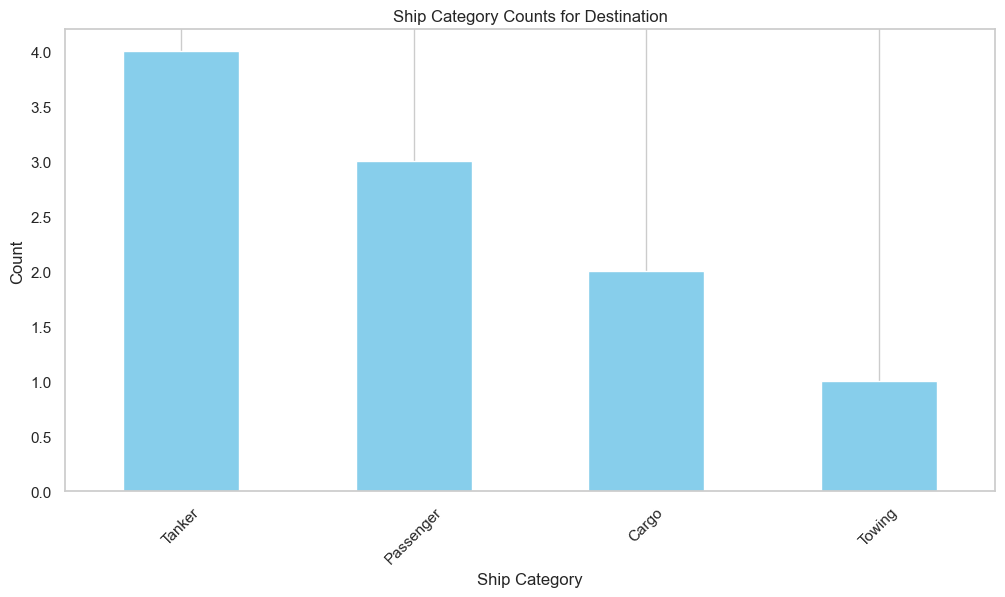

In [42]:
#visualize the ship category and count occurrences of each category in a bar chart
if 'destination_df' in locals() and not destination_df.empty and 'ShipCategory' in destination_df.columns:
    category_counts = destination_df['ShipCategory'].value_counts()
    plt.figure(figsize=(12, 6))
    category_counts.plot(kind='bar', color='skyblue')
    plt.title('Ship Category Counts for Destination')
    plt.xlabel('Ship Category')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.show()
else:
    print("destination_df is not available or missing the 'ShipCategory' column.")

{'error': {'code': 400, 'message': 'Item does not exist or is inaccessible.', 'messageCode': 'CONT_0001', 'details': ['Item does not exist or is inaccessible.']}}


In [85]:
import requests
import pandas as pd

def query_daily_port_data(port_id=None):
    url = "https://services9.arcgis.com/weJ1QsnbMYJlCHdG/arcgis/rest/services/Daily_Ports_Data/FeatureServer/0/query"
    
    where_clause = f"portid = '{port_id.lower()}'" if port_id else "1=1"
    
    params = {
        "where": where_clause,
        "outFields": "year,month,day,portid,portname,import_container,import_dry_bulk,import_general_cargo,import_roro,import_tanker",
        "maxRecordCountFactor": 5,
        "outSR": 4326,
        "f": "json"
    }
    
    response = requests.get(url, params=params)
    response.raise_for_status()
    return response.json()

if __name__ == "__main__":
    data = query_daily_port_data("port474")
    features = data.get("features", [])
    
    if features:
        shipping_df = pd.DataFrame([f["attributes"] for f in features])
        
        # Sort if year, month, day are available
        if {"year", "month", "day"}.issubset(shipping_df.columns):
            shipping_df = shipping_df.sort_values(["year", "month", "day"])
            
        print("data exists")
    else:
        print("No records found.")

data exists


In [87]:
shipping_df.head(5)

,year,month,day,portid,portname,import_container,import_dry_bulk,import_general_cargo,import_roro,import_tanker
0,2019,1,1,port474,Hong Kong,240177,35845,4514,2464,35992
1,2019,1,2,port474,Hong Kong,309051,66648,3486,0,49272
2,2019,1,3,port474,Hong Kong,444601,57405,6423,2815,45489
3,2019,1,4,port474,Hong Kong,458225,54373,1504,0,95954
4,2019,1,5,port474,Hong Kong,400019,0,21680,0,219592


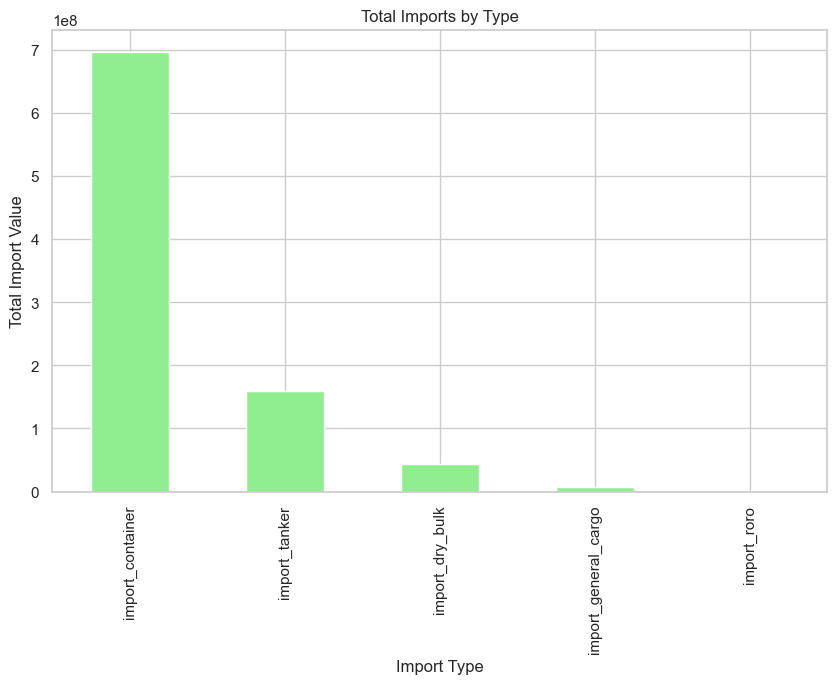

In [88]:
#visualize the import types and sort them in descending order
import_types = ['import_container', 'import_dry_bulk', 'import_general_cargo', 'import_roro', 'import_tanker']
import_sums = df[import_types].sum()
import_sums_sorted = import_sums.sort_values(ascending=False)
import_sums_sorted.plot(kind='bar', color='lightgreen', figsize=(10, 6))
plt.title('Total Imports by Type')
plt.xlabel('Import Type')
plt.ylabel('Total Import Value')
plt.show()

In [90]:
def query_port_database(port_id):
    url = "https://services9.arcgis.com/weJ1QsnbMYJlCHdG/arcgis/rest/services/PortWatch_ports_database/FeatureServer/0/query"
    
    params = {
        "where": f"portid = '{port_id.lower()}'",
        "outFields": "portid,portname,country,industry_top1,industry_top2,industry_top3",
        "returnGeometry": "false",
        "outSR": 4326,
        "f": "json"
    }
    
    response = requests.get(url, params=params)
    response.raise_for_status()
    return response.json()

if __name__ == "__main__":
    data = query_port_database("PORT474")
    features = data.get("features", [])
    
    if features:
        industry_df = pd.DataFrame([f["attributes"] for f in features])
        print("Records found")
    else:
        print("No records found.")

Records found


In [91]:
industry_df.head(5)

,portid,portname,country,industry_top1,industry_top2,industry_top3
0,port474,Hong Kong,Hong Kong SAR,Mineral Products,Vegetable Products,Prepared Foodstuffs & Beverages
